In [9]:
import cv2
import glob 
import matplotlib.pyplot as plt
import pandas as pd

In [13]:
image = cv2.imread('/Users/cmbreen/Documents/snow/alaska_dataset/all_images/BC_final_448/BC1TLDA/BC1TLDA_WSCT4923.JPG')
filename = 'BC1TLDA_WSCT4923.JPG'

labels = pd.read_csv('/Users/cmbreen/Documents/snow/alaska_dataset/all_images/labels.csv')
keypoints = labels[labels['filename']== filename][['x1','x2','y1','y2']]
keypoints

,x1,x2,y1,y2
153,221.696364,199.296364,98.118182,395.427273


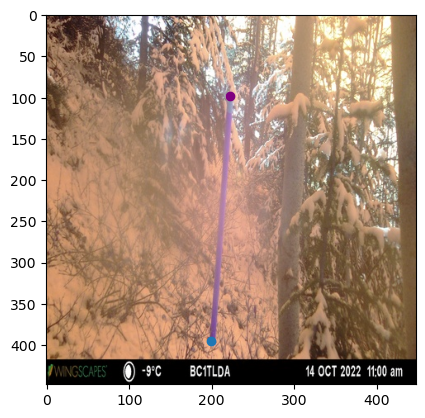

In [18]:
plt.imshow(image)
plt.scatter(keypoints['x1'],keypoints['y1'], c='purple')
plt.scatter(keypoints['x2'],keypoints['y2'])

153    71.696364
Name: x1, dtype: float64 153    48.118182
Name: y1, dtype: float64 153    49.296364
Name: x2, dtype: float64 153    345.427273
Name: y2, dtype: float64


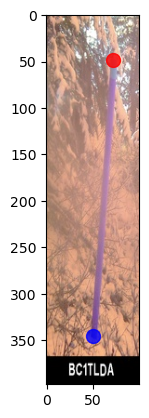

In [ ]:
plt.imshow(image[50:450,150:250])

x1_crop = keypoints['x1'] - 150  # 221.696364 - 150 = 71.696364
y1_crop = keypoints['y1'] - 50   # 98.118182 - 50 = 48.118182
x2_crop = keypoints['x2'] - 150  # 199.296364 - 150 = 49.296364
y2_crop = keypoints['y2'] -  50   # 395.427273 - 50 = 345.427273
print(x1_crop,y1_crop,x2_crop, y2_crop )

plt.scatter(x1_crop, y1_crop, s=100, c='red', marker='o', alpha=0.8, label='Point 1')
plt.scatter(x2_crop, y2_crop, s=100, c='blue', marker='o', alpha=0.8, label='Point 2')


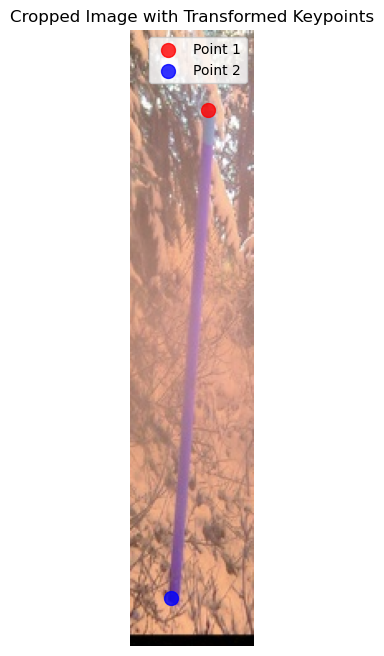

In [26]:
def plot_keypoints_on_crop(image, keypoints, crop_slice, figsize=(8, 8)):
    """
    Plot keypoints on a cropped image with automatic coordinate transformation
    
    Args:
        image: Original image array
        keypoints: Dictionary with keypoint coordinates
        crop_slice: Tuple of (row_slice, col_slice) e.g., (slice(50, 450), slice(150, 250))
        figsize: Figure size for plotting
    """
    # Extract crop parameters
    row_slice, col_slice = crop_slice
    y_start = row_slice.start
    x_start = col_slice.start
    
    # Create cropped image
    cropped_image = image[row_slice, col_slice]
    
    # Transform all keypoints automatically
    transformed_keypoints = {}
    for key, value in keypoints.items():
        if key.startswith('x'):
            transformed_keypoints[key] = value - x_start
        elif key.startswith('y'):
            transformed_keypoints[key] = value - y_start
    
    # Plot
    plt.figure(figsize=figsize)
    plt.imshow(cropped_image)
    
    # Plot keypoints (assuming x1,y1 and x2,y2 pairs)
    plt.scatter(transformed_keypoints['x1'], transformed_keypoints['y1'], 
               s=100, c='red', marker='o', alpha=0.8, label='Point 1')
    plt.scatter(transformed_keypoints['x2'], transformed_keypoints['y2'], 
               s=100, c='blue', marker='o', alpha=0.8, label='Point 2')
    
    plt.legend()
    plt.axis('off')
    plt.title('Cropped Image with Transformed Keypoints')
    plt.show()
    
    return transformed_keypoints

# Usage:
crop_region = (slice(50, 425), slice(175, 250))
transformed_kpts = plot_keypoints_on_crop(image, keypoints, crop_region)